# Geo Snap — Task 1B: Multispectral Land-Use Classification (GoogLeNet, 13-band)

Same GoogLeNet pipeline as the RGB notebook, adapted for the 13-band Sentinel-2
`.tif` patches. Three things differ from RGB, and each one silently corrupts
training if skipped:

1. **Reading `.tif`.** The patches are 13-band GeoTIFFs of raw Sentinel-2
   reflectance (`uint16`), read with `rasterio` (channel-first, file band order).
2. **Per-band normalisation.** Reflectance is not 0–255 and every band has a
   different range, so we compute per-band mean/std over the *training* set and
   standardise — we do **not** divide by 255 or reuse ImageNet stats.
3. **3→13 channel stem.** GoogLeNet's first conv takes 3 channels; we replace it
   with a 13-channel conv, copy the pretrained R/G/B filters onto the matching
   Sentinel bands (B04/B03/B02), and seed the other 10 bands with the average
   filter. We also set **`transform_input = False`** — the built-in transform
   assumes 3 RGB channels and would *drop* bands 3–12.

Band order used (EuroSAT all-bands convention, 0-indexed):
`B01 B02 B03 B04 B05 B06 B07 B08 B8A B09 B10 B11 B12`

## 1. Setup

In [1]:
!pip install -q rasterio
import csv, glob, json, os, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import googlenet, GoogLeNet_Weights
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.11.0+cu128


In [2]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
ZIP = "/content/drive/MyDrive/EuroSAT_Dataset.zip"
print("exists:", os.path.exists(ZIP))

!unzip -nq "{ZIP}" -d data
print("Unzip done")

exists: True
Unzip done


In [4]:
import os, pandas as pd

print("inside EuroSAT/:", sorted(os.listdir("data/EuroSAT"))[:12])
print("train/ exists:", os.path.isdir("data/EuroSAT/train"),
      "| val/ exists:", os.path.isdir("data/EuroSAT/val"))
print("test_flat exists:", os.path.isdir("data/EuroSAT_test_flat"),
      "| count:", len(os.listdir("data/EuroSAT_test_flat")))

df = pd.read_csv("data/train.csv")
print("\ntrain.csv columns:", list(df.columns))
print(df.head(3).to_string())

inside EuroSAT/: ['train', 'val']
train/ exists: True | val/ exists: True
test_flat exists: True | count: 4050

train.csv columns: ['filename', 'label', 'classname']
                         filename  label   classname
0   AnnualCrop\AnnualCrop_683.jpg      0  AnnualCrop
1  AnnualCrop\AnnualCrop_2035.jpg      0  AnnualCrop
2   AnnualCrop\AnnualCrop_842.jpg      0  AnnualCrop


In [5]:
import json, pandas as pd
df = pd.read_csv("data/train.csv")
label_map = (df[["classname", "label"]].drop_duplicates()
             .set_index("classname")["label"].astype(int).to_dict())
label_map = dict(sorted(label_map.items(), key=lambda kv: kv[1]))
with open("data/label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)
print(label_map)

# settle img_id format while we're here:
import os
print("test files:", sorted(os.listdir("data/EuroSAT_test_flat"))[:5])

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
test files: ['test_1.jpg', 'test_10.jpg', 'test_100.jpg', 'test_1000.jpg', 'test_1001.jpg']


In [6]:
DATA_ROOT = "data/EuroSAT"
TRAIN_DIR = "data/EuroSAT/train"
VAL_DIR   = "data/EuroSAT/val"
LABEL_MAP = "data/label_map.json"
TEST_DIR  = "data/EuroSAT_test_flat"

In [7]:
import os
for name, p in [("TRAIN_DIR", TRAIN_DIR), ("VAL_DIR", VAL_DIR),
                ("LABEL_MAP", LABEL_MAP), ("TEST_DIR", TEST_DIR)]:
    print(f"{name:10s} {'OK     ' if os.path.exists(p) else 'MISSING'}  {p}")

TRAIN_DIR  OK       data/EuroSAT/train
VAL_DIR    OK       data/EuroSAT/val
LABEL_MAP  OK       data/label_map.json
TEST_DIR   OK       data/EuroSAT_test_flat


## 2. Config — edit paths to match the all-bands data

In [8]:
# ---- paths (EDIT) ----
DATA_ROOT  = "data/EuroSATallBands"
TRAIN_DIR  = f"{DATA_ROOT}/train"
VAL_DIR    = f"{DATA_ROOT}/val"
LABEL_MAP  = "data/label_map.json"          # the one we built from train.csv
TEST_DIR   = "data/EuroSATallBands_test_flat"
STATS_PATH = "data/ms_band_stats.json"      # cached per-band mean/std
CKPT_PATH  = "googlenet_ms_best.pt"
PRED_CSV   = "ms_predictions.csv"

# ---- hyperparameters ----
IN_CHANNELS  = 13
IMG_SIZE     = 224      # upscaled from 64x64, same as RGB
BATCH_SIZE   = 64       # drop to 32 if you hit OOM
EPOCHS       = 20
LR           = 3e-4
WEIGHT_DECAY = 1e-4
WORKERS      = 2
SEED         = 42

# ---- submission format (match RGB / any sample submission) ----
LABEL_FORMAT = "name"
KEEP_EXT     = False

In [9]:
import os, glob
for name, p in [("TRAIN_DIR", TRAIN_DIR), ("VAL_DIR", VAL_DIR),
                ("LABEL_MAP", LABEL_MAP), ("TEST_DIR", TEST_DIR)]:
    print(f"{name:10s} {'OK     ' if os.path.exists(p) else 'MISSING'}  {p}")

if os.path.isdir(TEST_DIR):
    print("\ntest .tif count:", len(glob.glob(os.path.join(TEST_DIR, "*.tif"))), "(expect 4050)")
if os.path.isdir(TRAIN_DIR):
    cls0 = sorted(os.listdir(TRAIN_DIR))[0]
    print("inside EuroSATallBands/:", sorted(os.listdir(DATA_ROOT))[:6])
    print("sample tif:", sorted(glob.glob(os.path.join(TRAIN_DIR, cls0, "*.tif")))[:1])

TRAIN_DIR  OK       data/EuroSATallBands/train
VAL_DIR    OK       data/EuroSATallBands/val
LABEL_MAP  OK       data/label_map.json
TEST_DIR   OK       data/EuroSATallBands_test_flat

test .tif count: 4050 (expect 4050)
inside EuroSATallBands/: ['train', 'val']
sample tif: ['data/EuroSATallBands/train/AnnualCrop/AnnualCrop_1.tif']


In [10]:
import json, pandas as pd
df = pd.read_csv("data/train.csv")
lm = (df[["classname","label"]].drop_duplicates()
      .set_index("classname")["label"].astype(int).to_dict())
json.dump(dict(sorted(lm.items(), key=lambda kv: kv[1])), open("data/label_map.json","w"), indent=2)
print("rebuilt label_map.json")

rebuilt label_map.json


## 3. Label map (shared with RGB)

In [11]:
def load_label_map(path):
    with open(path) as f:
        raw = json.load(f)
    class_to_idx = {}
    for k, v in raw.items():
        if isinstance(v, int) or (isinstance(v, str) and v.lstrip("-").isdigit()):
            class_to_idx[str(k)] = int(v)
        else:
            class_to_idx[str(v)] = int(k)
    return class_to_idx, {i: c for c, i in class_to_idx.items()}

class_to_idx, idx_to_class = load_label_map(LABEL_MAP)
num_classes = len(class_to_idx)
print(class_to_idx)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


## 4. Bands & reading `.tif`

`rasterio.read()` returns `(bands, H, W)` in file order. If rasterio fails to
install, we fall back to `tifffile`. If you're unsure of the band order in your
files, the true-color check in the next cell will tell you visually.

In [12]:
BAND_NAMES = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B10","B11","B12"]
RGB_BANDS  = (3, 2, 1)   # Red=B04, Green=B03, Blue=B02 (for weight transfer & true-color)
RED, NIR   = 3, 7        # B04, B08 -> used for NDVI in Task 2/3

try:
    import rasterio
    def read_tif(path):
        with rasterio.open(path) as src:
            return src.read().astype("float32")          # (bands, H, W)
except Exception:
    import tifffile
    def read_tif(path):
        a = tifffile.imread(path).astype("float32")
        return a.transpose(2, 0, 1) if a.ndim == 3 else a

_s = sorted(glob.glob(os.path.join(TRAIN_DIR, list(class_to_idx)[0], "*.tif")))[0]
print("sample:", _s, "-> shape", read_tif(_s).shape, "dtype", read_tif(_s).dtype)

sample: data/EuroSATallBands/train/AnnualCrop/AnnualCrop_1.tif -> shape (13, 64, 64) dtype float32


## 5. True-color sanity check (confirms band order)

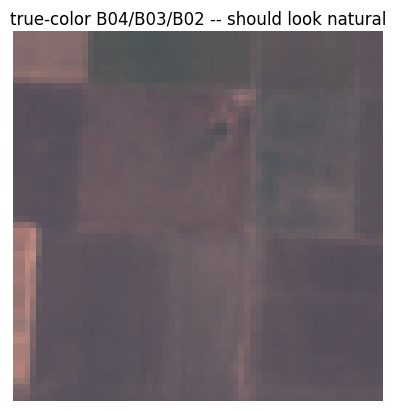

In [13]:
import matplotlib.pyplot as plt
arr = read_tif(_s)
tc = np.transpose(arr[list(RGB_BANDS)], (1, 2, 0))   # (H, W, 3) = R, G, B
tc = np.clip(tc / 3000.0, 0, 1)                       # display scaling for reflectance
plt.imshow(tc); plt.axis("off")
plt.title("true-color B04/B03/B02 -- should look natural"); plt.show()

## 6. Per-band normalisation stats

One pass over the training set to get per-band mean/std, cached to JSON so it
only runs once. Add `max_per_class=300` for a fast approximate estimate.

In [14]:
def compute_band_stats(train_dir, class_to_idx, max_per_class=None):
    s  = np.zeros(IN_CHANNELS, dtype=np.float64)
    ss = np.zeros(IN_CHANNELS, dtype=np.float64)
    n  = 0
    for cls in tqdm(class_to_idx, desc="band stats"):
        files = sorted(glob.glob(os.path.join(train_dir, cls, "*.tif")))
        if max_per_class:
            files = files[:max_per_class]
        for fp in files:
            a = read_tif(fp).reshape(IN_CHANNELS, -1)
            s  += a.sum(axis=1)
            ss += (a ** 2).sum(axis=1)
            n  += a.shape[1]
    mean = s / n
    std  = np.sqrt(np.maximum(ss / n - mean ** 2, 1e-8))
    return mean.astype("float32"), std.astype("float32")

if os.path.exists(STATS_PATH):
    d = json.load(open(STATS_PATH))
    MEAN, STD = np.array(d["mean"], "float32"), np.array(d["std"], "float32")
    print("loaded cached band stats")
else:
    MEAN, STD = compute_band_stats(TRAIN_DIR, class_to_idx)   # max_per_class=300 to speed up
    json.dump({"mean": MEAN.tolist(), "std": STD.tolist()}, open(STATS_PATH, "w"))
    print("computed and cached band stats ->", STATS_PATH)

for b, m, s in zip(BAND_NAMES, MEAN, STD):
    print(f"  {b:4s} mean {m:9.1f}  std {s:9.1f}")

band stats:   0%|          | 0/10 [00:00<?, ?it/s]

computed and cached band stats -> data/ms_band_stats.json
  B01  mean    1353.0  std     245.0
  B02  mean    1116.2  std     332.8
  B03  mean    1040.8  std     394.3
  B04  mean     944.9  std     593.4
  B05  mean    1197.6  std     565.8
  B06  mean    2002.4  std     860.0
  B07  mean    2373.8  std    1086.3
  B08  mean    2301.1  std    1117.6
  B8A  mean     732.8  std     404.0
  B09  mean      12.1  std       4.7
  B10  mean    1819.2  std    1000.7
  B11  mean    1116.9  std     759.3
  B12  mean    2599.5  std    1230.8


## 7. Transforms (tensor-based: augment -> normalise -> resize)

In [15]:
class MSTransform:
    def __init__(self, mean, std, img_size=224, train=True):
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std  = torch.tensor(std).view(-1, 1, 1)
        self.img_size = img_size
        self.train = train

    def __call__(self, arr):                       # arr: (13, H, W) float32
        x = torch.from_numpy(arr)
        if self.train:                             # D4 augmentation on the raw bands
            if random.random() < 0.5:
                x = torch.flip(x, dims=[2])
            if random.random() < 0.5:
                x = torch.flip(x, dims=[1])
            x = torch.rot90(x, k=random.randint(0, 3), dims=[1, 2]).contiguous()
        x = (x - self.mean) / (self.std + 1e-6)    # per-band standardisation
        x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                          mode="bilinear", align_corners=False).squeeze(0)
        return x

## 8. Datasets

In [16]:
class EuroSATMS(Dataset):
    def __init__(self, root, class_to_idx, transform=None):
        self.transform = transform
        self.samples = []
        for cls, idx in class_to_idx.items():
            d = os.path.join(root, cls)
            if not os.path.isdir(d):
                continue
            for fn in sorted(os.listdir(d)):
                if fn.lower().endswith(".tif"):
                    self.samples.append((os.path.join(d, fn), idx))
        if not self.samples:
            raise RuntimeError(f"No .tif under {root}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        arr = read_tif(path)
        return (self.transform(arr) if self.transform else torch.from_numpy(arr)), label

class EuroSATMSTestFlat(Dataset):
    def __init__(self, root, transform=None, keep_ext=False):
        self.transform = transform
        self.keep_ext = keep_ext
        self.paths = sorted(glob.glob(os.path.join(root, "*.tif")))
        if not self.paths:
            raise RuntimeError(f"No .tif under {root}")
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        path = self.paths[i]
        arr = read_tif(path)
        x = self.transform(arr) if self.transform else torch.from_numpy(arr)
        name = os.path.basename(path)
        return x, (name if self.keep_ext else os.path.splitext(name)[0])

## 9. Model — GoogLeNet with a 13-channel stem

`transform_input=False` is the critical line: the pretrained transform only
touches 3 channels and would discard bands 3–12. The new stem conv copies the
pretrained R/G/B filters onto B04/B03/B02 and seeds the remaining bands with the
mean pretrained filter, so all 13 inputs start from a sensible (non-random)
state.

In [17]:
def build_googlenet_ms(num_classes=10, in_channels=13, pretrained=True, rgb_bands=RGB_BANDS):
    weights = GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None
    model = googlenet(weights=weights, aux_logits = False)
    model.transform_input = False                 # CRITICAL for >3 channels
    old = model.conv1.conv                          # Conv2d(3, 64, 7, stride 2, pad 3)
    new = nn.Conv2d(in_channels, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=(old.bias is not None))
    with torch.no_grad():
        if pretrained:
            w = old.weight                          # (64, 3, 7, 7)
            new.weight.copy_(w.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1))
            for src_c, band in enumerate(rgb_bands):   # pretrained R,G,B -> B04,B03,B02
                new.weight[:, band] = w[:, src_c]
    model.conv1.conv = new
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    # if getattr(model, "aux_logits", False):
    #     model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    #     model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    return model

## 10. Smoke test

In [18]:
def build_googlenet_ms(num_classes=10, in_channels=13, pretrained=True, rgb_bands=RGB_BANDS):
    weights = GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None
    model = googlenet(weights=weights, aux_logits=True)    # <-- keep the aux heads
    model.transform_input = False
    old = model.conv1.conv
    new = nn.Conv2d(in_channels, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=(old.bias is not None))
    with torch.no_grad():
        if pretrained:
            w = old.weight
            new.weight.copy_(w.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1))
            for src_c, band in enumerate(rgb_bands):
                new.weight[:, band] = w[:, src_c]
    model.conv1.conv = new
    model.fc   = nn.Linear(model.fc.in_features, num_classes)
    model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    return model

## 11. Train / eval helpers (identical to RGB)

In [19]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def run_epoch(model, loader, criterion, optimizer, scaler, device, train, aux_weight=0.3):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.set_grad_enabled(train):
            with torch.amp.autocast(device_type='cuda', enabled=scaler is not None):
                out = model(images)
                if torch.is_tensor(out):
                    logits = out
                    loss = criterion(logits, labels)
                else:
                    logits = out.logits
                    loss = (criterion(logits, labels)
                            + aux_weight * criterion(out.aux_logits1, labels)
                            + aux_weight * criterion(out.aux_logits2, labels))
            if train:
                optimizer.zero_grad()
                if scaler is not None:
                    scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
                else:
                    loss.backward(); optimizer.step()
        loss_sum += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def per_class_accuracy(model, loader, device, num_classes, idx_to_class):
    model.eval()
    correct = np.zeros(num_classes); total = np.zeros(num_classes)
    for images, labels in tqdm(loader, leave=False):
        preds = model(images.to(device)).argmax(1).cpu().numpy()
        labels = labels.numpy()
        for p, t in zip(preds, labels):
            total[t] += 1; correct[t] += int(p == t)
    return {idx_to_class[i]: (correct[i] / total[i] if total[i] else float("nan"))
            for i in range(num_classes)}

## 12. Train

In [20]:
set_seed(SEED)
tf_train = MSTransform(MEAN, STD, IMG_SIZE, train=True)
tf_eval  = MSTransform(MEAN, STD, IMG_SIZE, train=False)

train_ds = EuroSATMS(TRAIN_DIR, class_to_idx, tf_train)
val_ds   = EuroSATMS(VAL_DIR,   class_to_idx, tf_eval)
train_ld = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=WORKERS,
                      pin_memory=False, drop_last=True, persistent_workers = True)
val_ld   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=WORKERS,
                      pin_memory=False, persistent_workers=True)
print(f"train={len(train_ds)}  val={len(val_ds)}")

model = build_googlenet_ms(num_classes, IN_CHANNELS).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler(device='cuda') if device == "cuda" else None

history = {"train_acc": [], "val_acc": []}
best_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_ld, criterion, optimizer, scaler, device, True)
    va_loss, va_acc = run_epoch(model, val_ld, criterion, None, None, device, False)
    scheduler.step()
    history["train_acc"].append(tr_acc); history["val_acc"].append(va_acc)
    print(f"epoch {epoch:02d}  train_loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val_loss {va_loss:.4f} acc {va_acc:.4f}")
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"model": model.state_dict(), "class_to_idx": class_to_idx,
                    "img_size": IMG_SIZE, "in_channels": IN_CHANNELS,
                    "mean": MEAN.tolist(), "std": STD.tolist(), "val_acc": best_acc}, CKPT_PATH)
        print(f"  saved {CKPT_PATH} (val_acc {best_acc:.4f})")
print("\nbest val acc:", round(best_acc, 4))

train=18900  val=4050
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 93.7MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


  0%|          | 0/295 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

epoch 01  train_loss 1.1473 acc 0.9385 | val_loss 0.5755 acc 0.9765
  saved googlenet_ms_best.pt (val_acc 0.9765)


...

  0%|          | 0/64 [00:00<?, ?it/s]

epoch 19  train_loss 0.8255 acc 0.9990 | val_loss 0.5228 acc 0.9923
  saved googlenet_ms_best.pt (val_acc 0.9923)


  0%|          | 0/295 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

epoch 20  train_loss 0.8255 acc 0.9990 | val_loss 0.5221 acc 0.9921

best val acc: 0.9923


In [21]:
# ---- continue from the saved checkpoint for more epochs ----
EXTRA_EPOCHS = 10
RESUME_LR    = 1e-4    # smaller LR: the model's already converged, so fine-tune gently

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
best_acc = ckpt.get("val_acc", 0.0)
print(f"resumed from {CKPT_PATH} (val_acc {best_acc:.4f})")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=RESUME_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EXTRA_EPOCHS)
scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None

for epoch in range(1, EXTRA_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_ld, criterion, optimizer, scaler, device, True)
    va_loss, va_acc = run_epoch(model, val_ld, criterion, None, None, device, False)
    scheduler.step()
    history["train_acc"].append(tr_acc); history["val_acc"].append(va_acc)
    print(f"epoch {epoch:02d}+ train_loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val_loss {va_loss:.4f} acc {va_acc:.4f}")
    if va_acc > best_acc:                       # only overwrite if it actually beats 0.9921
        best_acc = va_acc
        torch.save({"model": model.state_dict(), "class_to_idx": class_to_idx,
                    "img_size": IMG_SIZE, "in_channels": IN_CHANNELS,
                    "mean": MEAN.tolist(), "std": STD.tolist(), "val_acc": best_acc}, CKPT_PATH)
        print(f"  saved {CKPT_PATH} (val_acc {best_acc:.4f})")
print("\nbest val acc:", round(best_acc, 4))

resumed from googlenet_ms_best.pt (val_acc 0.9923)


  0%|          | 0/295 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

epoch 01+ train_loss 0.8376 acc 0.9961 | val_loss 0.5239 acc 0.9909


  0%|          | 0/295 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

epoch 09+ train_loss 0.8211 acc 0.9994 | val_loss 0.5224 acc 0.9923


  0%|          | 0/295 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

epoch 10+ train_loss 0.8203 acc 0.9995 | val_loss 0.5224 acc 0.9931
  saved googlenet_ms_best.pt (val_acc 0.9931)

best val acc: 0.9931


## 13. Training curve

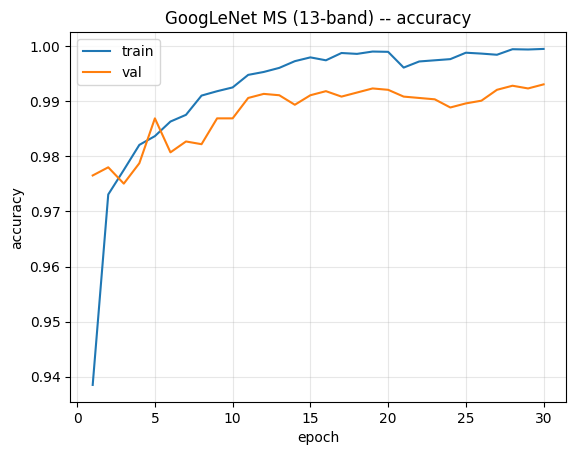

In [22]:
ep = range(1, len(history["train_acc"]) + 1)
plt.plot(ep, history["train_acc"], label="train")
plt.plot(ep, history["val_acc"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.grid(alpha=0.3)
plt.title("GoogLeNet MS (13-band) -- accuracy"); plt.show()

## 14. Per-class accuracy (reloads best checkpoint)

In [23]:
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model"]); model.eval()
for c, a in per_class_accuracy(model, val_ld, device, num_classes, idx_to_class).items():
    print(f"{c:22s} {a:.4f}")

  0%|          | 0/64 [00:00<?, ?it/s]

AnnualCrop             0.9867
Forest                 0.9978
HerbaceousVegetation   0.9867
Highway                0.9893
Industrial             0.9947
Pasture                0.9967
PermanentCrop          0.9920
Residential            0.9956
River                  0.9920
SeaLake                1.0000


## 15. Inference -> `ms_predictions.csv`

Uses the band stats stored in the checkpoint so the test set is normalised
exactly as training was. Output must have 4050 rows + header, same as RGB.

In [24]:
ckpt = torch.load(CKPT_PATH, map_location=device)
model = build_googlenet_ms(len(ckpt["class_to_idx"]), ckpt["in_channels"]).to(device)
model.load_state_dict(ckpt["model"]); model.eval()
idx_to_class = {i: c for c, i in ckpt["class_to_idx"].items()}

tf_test = MSTransform(np.array(ckpt["mean"], "float32"), np.array(ckpt["std"], "float32"),
                      ckpt["img_size"], train=False)
test_ds = EuroSATMSTestFlat(TEST_DIR, tf_test, keep_ext=KEEP_EXT)
test_ld = DataLoader(test_ds, 128, shuffle=False, num_workers=WORKERS, pin_memory=True)

rows = []
with torch.no_grad():
    for images, img_ids in tqdm(test_ld):
        preds = model(images.to(device)).argmax(1).cpu().tolist()
        for img_id, p in zip(img_ids, preds):
            rows.append((img_id, idx_to_class[p] if LABEL_FORMAT == "name" else p))

rows.sort(key=lambda r: r[0])
with open(PRED_CSV, "w", newline="") as f:
    w = csv.writer(f); w.writerow(["img_id", "predicted_label"]); w.writerows(rows)
print(f"wrote {len(rows)} predictions to {PRED_CSV}")
rows[:5]

  0%|          | 0/32 [00:00<?, ?it/s]

wrote 4050 predictions to ms_predictions.csv


[('test_1', 'AnnualCrop'),
 ('test_10', 'AnnualCrop'),
 ('test_100', 'AnnualCrop'),
 ('test_1000', 'HerbaceousVegetation'),
 ('test_1001', 'HerbaceousVegetation')]

In [25]:
import numpy as np, torch
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    ys, ps, cs = [], [], []
    for images, labels in tqdm(loader, leave=False):
        prob = torch.softmax(model(images.to(device)), dim=1)
        conf, pred = prob.max(1)
        ys.append(labels.numpy()); ps.append(pred.cpu().numpy()); cs.append(conf.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(cs)

classes = [idx_to_class[i] for i in range(num_classes)]
y_true, y_pred, y_conf = collect_preds(model, val_ld, device)
print("overall accuracy:", round(accuracy_score(y_true, y_pred), 4))

  0%|          | 0/64 [00:00<?, ?it/s]

overall accuracy: 0.9931


In [26]:
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

                      precision    recall  f1-score   support

          AnnualCrop     0.9955    0.9867    0.9911       450
              Forest     0.9978    0.9978    0.9978       450
HerbaceousVegetation     0.9933    0.9867    0.9900       450
             Highway     0.9973    0.9893    0.9933       375
          Industrial     0.9920    0.9947    0.9933       375
             Pasture     0.9739    0.9967    0.9852       300
       PermanentCrop     0.9815    0.9920    0.9867       375
         Residential     1.0000    0.9956    0.9978       450
               River     0.9920    0.9920    0.9920       375
             SeaLake     1.0000    1.0000    1.0000       450

            accuracy                         0.9931      4050
           macro avg     0.9923    0.9931    0.9927      4050
        weighted avg     0.9931    0.9931    0.9931      4050



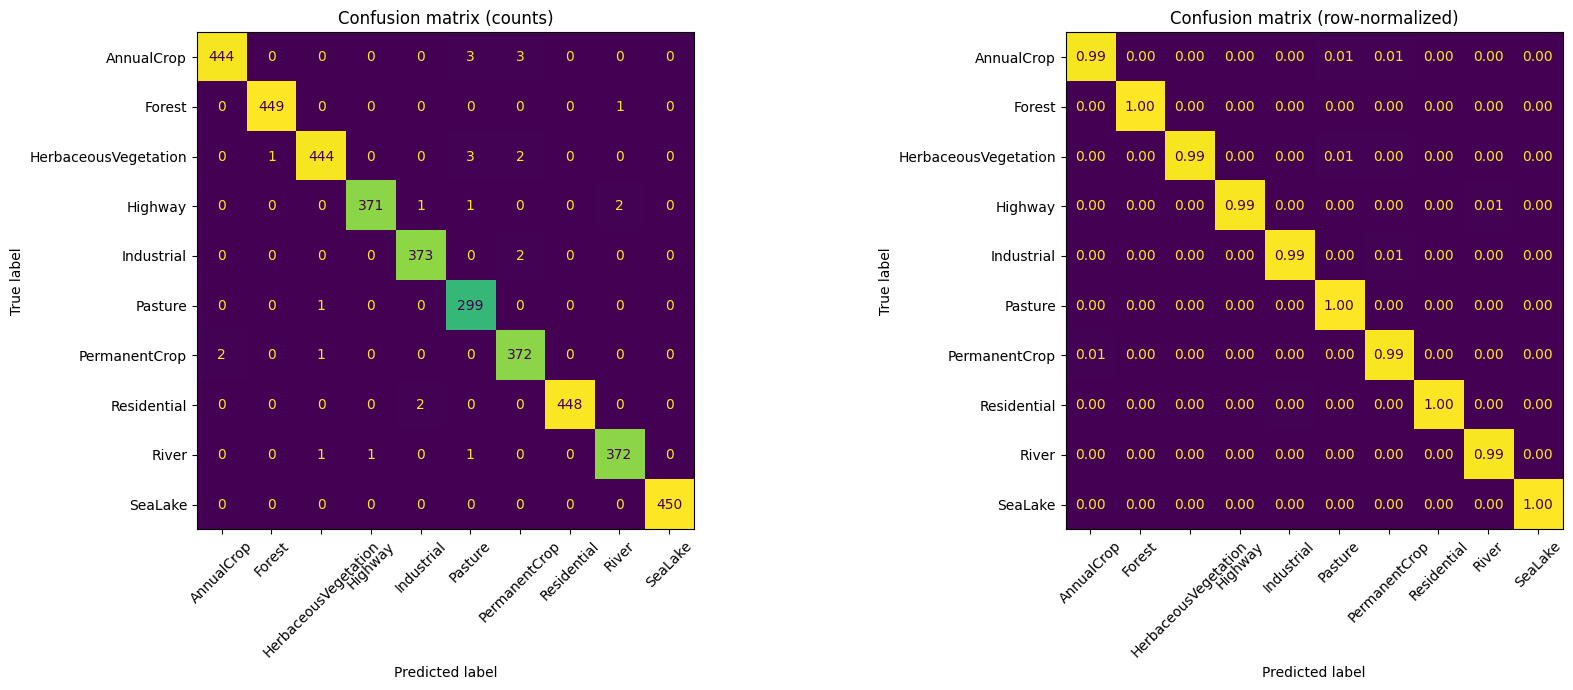

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=classes,
    xticks_rotation=45, ax=ax[0], colorbar=False)
ax[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=classes,
    normalize="true", values_format=".2f", xticks_rotation=45, ax=ax[1], colorbar=False)
ax[1].set_title("Confusion matrix (row-normalized)")
plt.tight_layout(); plt.savefig("ms_confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()

In [28]:
cm = confusion_matrix(y_true, y_pred)
pairs = [(cm[i, j], classes[i], classes[j])
         for i in range(num_classes) for j in range(num_classes)
         if i != j and cm[i, j] > 0]
pairs.sort(reverse=True)
print("Top confusions (true -> predicted):")
for cnt, t, p in pairs[:8]:
    print(f"  {t:22s} -> {p:22s} {cnt}")

# the model's most confident wrong calls — best candidates for Grad-CAM in Task 2A
wrong = np.where(y_true != y_pred)[0]
worst = wrong[np.argsort(-y_conf[wrong])][:10]
print("\nMost confident mistakes:")
for i in worst:
    print(f"  true {classes[y_true[i]]:20s} pred {classes[y_pred[i]]:20s} conf {y_conf[i]:.3f}")

Top confusions (true -> predicted):
  HerbaceousVegetation   -> Pasture                3
  AnnualCrop             -> PermanentCrop          3
  AnnualCrop             -> Pasture                3
  Residential            -> Industrial             2
  PermanentCrop          -> AnnualCrop             2
  Industrial             -> PermanentCrop          2
  Highway                -> River                  2
  HerbaceousVegetation   -> PermanentCrop          2

Most confident mistakes:
  true PermanentCrop        pred HerbaceousVegetation conf 0.931
  true Forest               pred River                conf 0.929
  true Highway              pred River                conf 0.918
  true Residential          pred Industrial           conf 0.917
  true Pasture              pred HerbaceousVegetation conf 0.906
  true PermanentCrop        pred AnnualCrop           conf 0.901
  true HerbaceousVegetation pred Pasture              conf 0.898
  true River                pred Pasture              conf 

In [39]:
import os
import pandas as pd

rows = []
for split, root in [("train", TRAIN_DIR), ("val", VAL_DIR)]:
    for cls in sorted(os.listdir(root)):
        path = os.path.join(root, cls)
        if os.path.isdir(path):
            rows.append({
                "split": split,
                "class": cls,
                "count": len([f for f in os.listdir(path) if f.endswith(".tif")])
            })

pd.DataFrame(rows)

,split,class,count
0,train,AnnualCrop,2100
1,train,Forest,2100
2,train,HerbaceousVegetation,2100
3,train,Highway,1750
4,train,Industrial,1750
5,train,Pasture,1400
6,train,PermanentCrop,1750
7,train,Residential,2100
8,train,River,1750
9,train,SeaLake,2100


In [41]:
print(model)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, trac

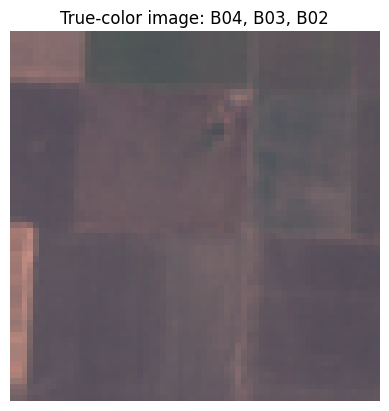

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import glob, os

sample = sorted(glob.glob(os.path.join(TRAIN_DIR, list(class_to_idx)[0], "*.tif")))[0]
arr = read_tif(sample)

rgb = arr[[3, 2, 1]]
rgb = np.transpose(rgb, (1, 2, 0))
rgb = np.clip(rgb / 3000.0, 0, 1)

plt.imshow(rgb)
plt.title("True-color image: B04, B03, B02")
plt.axis("off")
plt.show()

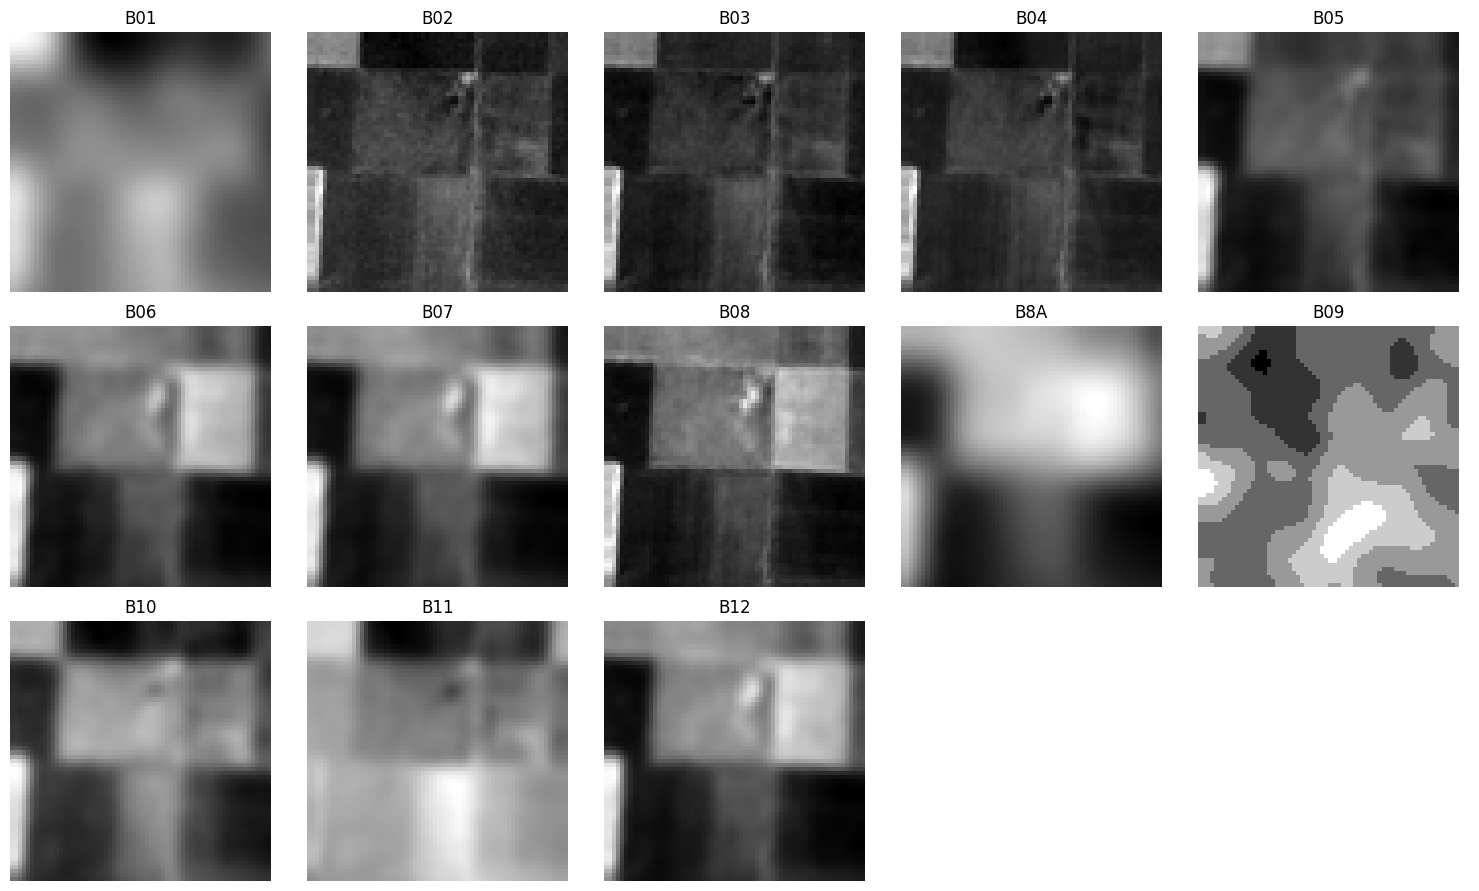

In [43]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

for i, band in enumerate(BAND_NAMES):
    axes[i].imshow(arr[i], cmap="gray")
    axes[i].set_title(band)
    axes[i].axis("off")

for j in range(len(BAND_NAMES), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

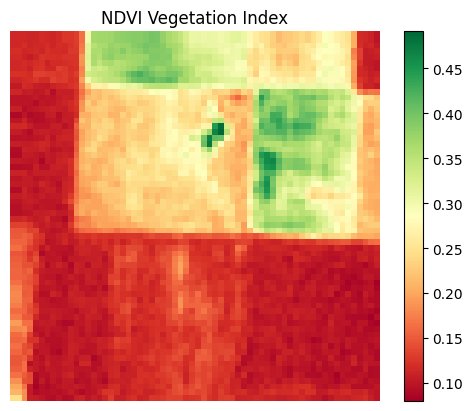

In [44]:
red = arr[3]   # B04
nir = arr[7]   # B08

ndvi = (nir - red) / (nir + red + 1e-6)

plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar()
plt.title("NDVI Vegetation Index")
plt.axis("off")
plt.show()

## 16. RGB vs MS — completing Part 1

With both notebooks trained you have the two per-class accuracy tables. The Task 1
question ("does spectral information help?") is read off the classes that are
visually similar but spectrally distinct:

- **AnnualCrop vs PermanentCrop**
- **Pasture vs HerbaceousVegetation**

If MS lifts accuracy on those specific classes more than on the easy ones
(SeaLake, Forest), that's your evidence that the extra bands carry real signal —
which is exactly the story Task 2 (band importance) and Task 3 (NDVI/NDWI) build
on. The `RED`/`NIR` band indices defined above are your starting point for NDVI.

## 17. Bonus ? Environmental Interpretation

This section turns the trained land-use classifier into a small environmental analysis. Instead of only asking whether the model is accurate, we use Sentinel-2 spectral indices and band reflectance patterns to ask what the predicted land classes imply about vegetation, water, and crop structure.


### 17.1 Helper functions for spectral indices

NDVI measures vegetation strength using near-infrared and red light. NDWI measures water content/water presence using green and near-infrared light. Both are computed directly from the original 13-band `.tif` patches before normalization.


In [29]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Sentinel-2 band indices in this notebook's order:
# B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B10,B11,B12
BLUE  = 1   # B02
GREEN = 2   # B03
RED   = 3   # B04
NIR   = 7   # B08
SWIR1 = 11  # B11
SWIR2 = 12  # B12

INDEX_EPS = 1e-6

def safe_index(a, b):
    return (a - b) / (a + b + INDEX_EPS)

def patch_indices(arr):
    """Return mean NDVI, NDWI, and MNDWI for one 13-band patch."""
    ndvi = safe_index(arr[NIR], arr[RED])       # vegetation: (B08 - B04) / (B08 + B04)
    ndwi = safe_index(arr[GREEN], arr[NIR])     # water:      (B03 - B08) / (B03 + B08)
    mndwi = safe_index(arr[GREEN], arr[SWIR1])  # water/built-up separation: (B03 - B11) / (B03 + B11)
    return {
        "ndvi_mean": float(np.nanmean(ndvi)),
        "ndwi_mean": float(np.nanmean(ndwi)),
        "mndwi_mean": float(np.nanmean(mndwi)),
        "ndvi_gt_02": float(np.nanmean(ndvi > 0.2)),
        "ndwi_gt_02": float(np.nanmean(ndwi > 0.2)),
        "mndwi_gt_02": float(np.nanmean(mndwi > 0.2)),
    }

def class_files(root, class_to_idx, max_per_class=None):
    rows = []
    for cls in sorted(class_to_idx):
        files = sorted(glob.glob(os.path.join(root, cls, "*.tif")))
        if max_per_class is not None:
            files = files[:max_per_class]
        rows.extend((cls, fp) for fp in files)
    return rows

def compute_index_table(root, class_to_idx, max_per_class=None):
    rows = []
    for cls, fp in tqdm(class_files(root, class_to_idx, max_per_class), desc="spectral indices"):
        vals = patch_indices(read_tif(fp))
        vals.update({"class": cls, "path": fp})
        rows.append(vals)
    return pd.DataFrame(rows)

# Use max_per_class=300 for a fast first run. Set to None for the full training set.
index_df = compute_index_table(TRAIN_DIR, class_to_idx, max_per_class=300)
index_df.head()


spectral indices:   0%|          | 0/3000 [00:00<?, ?it/s]

,ndvi_mean,ndwi_mean,mndwi_mean,ndvi_gt_02,ndwi_gt_02,mndwi_gt_02,class,path
0,0.188847,-0.240202,-0.305691,0.419922,0.0,0.000000,AnnualCrop,data/EuroSATallBands/train/AnnualCrop/AnnualCr...
1,0.348173,-0.368921,-0.125643,0.501953,0.0,0.114014,AnnualCrop,data/EuroSATallBands/train/AnnualCrop/AnnualCr...
2,0.390693,-0.391166,-0.238267,0.665771,0.0,0.000000,AnnualCrop,data/EuroSATallBands/train/AnnualCrop/AnnualCr...
3,0.599980,-0.493059,0.125600,0.935791,0.0,0.333252,AnnualCrop,data/EuroSATallBands/train/AnnualCrop/AnnualCr...
4,0.344521,-0.437107,0.011354,0.999268,0.0,0.000000,AnnualCrop,data/EuroSATallBands/train/AnnualCrop/AnnualCr...


### 17.2 Vegetation health map idea ? NDVI by class

This plot shows how vegetation-related classes differ from built-up or water classes. High NDVI means strong vegetation signal; near-zero or negative NDVI usually means little vegetation, water, buildings, roads, or bare surfaces.


/tmp/ipykernel_3182/3973022141.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([index_df.loc[index_df["class"] == cls, "ndvi_mean"] for cls in order], labels=order, showfliers=False)


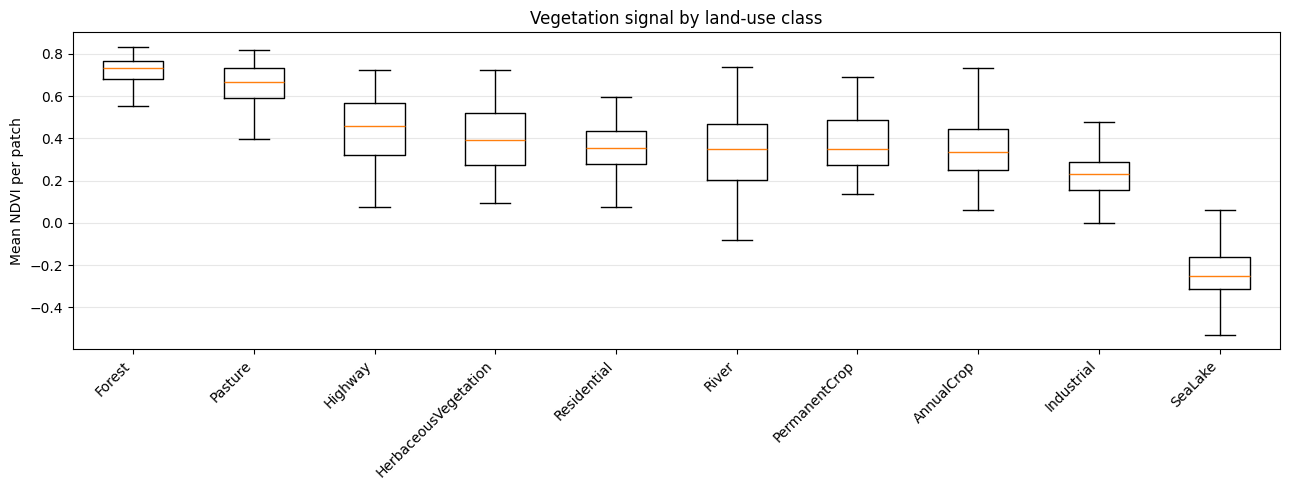

,count,mean,median,std
class,,,,
Forest,300,0.718507,0.731024,0.066471
Pasture,300,0.651146,0.665796,0.107890
Highway,300,0.440605,0.456553,0.158072
HerbaceousVegetation,300,0.390466,0.390838,0.151218
Residential,300,0.346840,0.352750,0.110753
River,300,0.338787,0.349910,0.179432
PermanentCrop,300,0.376018,0.348890,0.126542
AnnualCrop,300,0.362235,0.334497,0.156567
Industrial,300,0.228502,0.228922,0.094453


In [30]:
order = index_df.groupby("class")["ndvi_mean"].median().sort_values(ascending=False).index

plt.figure(figsize=(13, 5))
plt.boxplot([index_df.loc[index_df["class"] == cls, "ndvi_mean"] for cls in order], labels=order, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean NDVI per patch")
plt.title("Vegetation signal by land-use class")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

ndvi_summary = (index_df.groupby("class")["ndvi_mean"]
                .agg(["count", "mean", "median", "std"])
                .sort_values("median", ascending=False))
ndvi_summary


In [31]:
vegetation_classes = [c for c in ["Forest", "HerbaceousVegetation", "Pasture", "PermanentCrop", "AnnualCrop"] if c in index_df["class"].unique()]
built_classes = [c for c in ["Industrial", "Residential", "Highway"] if c in index_df["class"].unique()]

print("Environmental interpretation from NDVI:")
if vegetation_classes:
    print("Vegetation classes median NDVI:")
    print(ndvi_summary.loc[vegetation_classes, "median"].sort_values(ascending=False).round(3))
if built_classes:
    print("\nBuilt-up / road classes median NDVI:")
    print(ndvi_summary.loc[built_classes, "median"].sort_values(ascending=False).round(3))


Environmental interpretation from NDVI:
Vegetation classes median NDVI:
class
Forest                  0.731
Pasture                 0.666
HerbaceousVegetation    0.391
PermanentCrop           0.349
AnnualCrop              0.334
Name: median, dtype: float64

Built-up / road classes median NDVI:
class
Highway        0.457
Residential    0.353
Industrial     0.229
Name: median, dtype: float64


### 17.3 Water body analysis ? NDWI/MNDWI by class

NDWI and MNDWI highlight water. River and SeaLake patches should generally have stronger water-index values than Residential or Industrial patches. The threshold columns estimate what fraction of pixels in a patch look water-like.


/tmp/ipykernel_3182/4074166420.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([plot_df.loc[plot_df["class"] == cls, "ndwi_mean"] for cls in order], labels=order, showfliers=False)
/tmp/ipykernel_3182/4074166420.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([plot_df.loc[plot_df["class"] == cls, "mndwi_mean"] for cls in order], labels=order, showfliers=False)


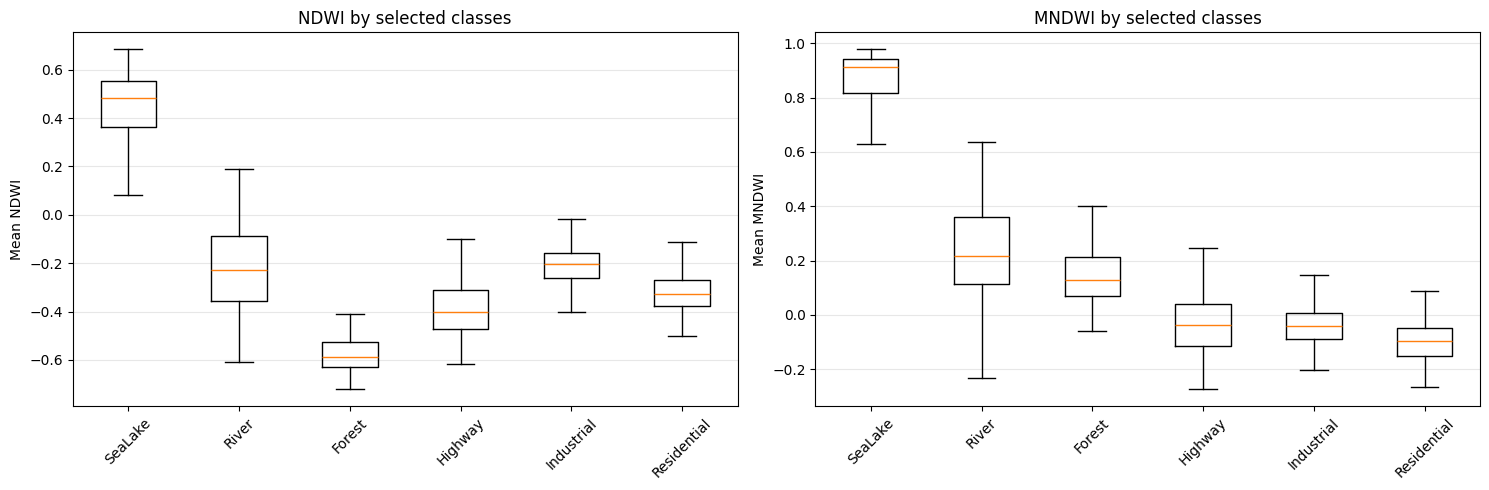

,ndwi_mean,mndwi_mean,ndwi_gt_02,mndwi_gt_02
class,,,,
SeaLake,0.483233,0.914239,1.000000,1.000000
River,-0.228519,0.217516,0.197754,0.376099
Forest,-0.587934,0.126928,0.000000,0.104004
Pasture,-0.560576,0.010601,0.000000,0.000732
Highway,-0.402460,-0.038472,0.000000,0.008789
Industrial,-0.203906,-0.042177,0.000000,0.025024
AnnualCrop,-0.379976,-0.092800,0.000000,0.000000
Residential,-0.329370,-0.095009,0.000000,0.001221
HerbaceousVegetation,-0.377731,-0.142624,0.000000,0.000000


In [32]:
water_focus = [c for c in ["River", "SeaLake", "Residential", "Industrial", "Highway", "Forest"] if c in index_df["class"].unique()]
plot_df = index_df[index_df["class"].isin(water_focus)].copy()
order = plot_df.groupby("class")["mndwi_mean"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].boxplot([plot_df.loc[plot_df["class"] == cls, "ndwi_mean"] for cls in order], labels=order, showfliers=False)
ax[0].set_title("NDWI by selected classes")
ax[0].set_ylabel("Mean NDWI")
ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(axis="y", alpha=0.3)

ax[1].boxplot([plot_df.loc[plot_df["class"] == cls, "mndwi_mean"] for cls in order], labels=order, showfliers=False)
ax[1].set_title("MNDWI by selected classes")
ax[1].set_ylabel("Mean MNDWI")
ax[1].tick_params(axis="x", rotation=45)
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

water_summary = (index_df.groupby("class")[["ndwi_mean", "mndwi_mean", "ndwi_gt_02", "mndwi_gt_02"]]
                 .median()
                 .sort_values("mndwi_mean", ascending=False))
water_summary


In [33]:
print("Water-mask interpretation using MNDWI > 0.2:")
cols = ["mndwi_mean", "mndwi_gt_02"]
for cls in ["SeaLake", "River", "Residential", "Industrial"]:
    if cls in water_summary.index:
        print(f"{cls:12s} median MNDWI={water_summary.loc[cls, 'mndwi_mean']:.3f}, "
              f"median water-like pixel fraction={water_summary.loc[cls, 'mndwi_gt_02']:.3f}")


Water-mask interpretation using MNDWI > 0.2:
SeaLake      median MNDWI=0.914, median water-like pixel fraction=1.000
River        median MNDWI=0.218, median water-like pixel fraction=0.376
Residential  median MNDWI=-0.095, median water-like pixel fraction=0.001
Industrial   median MNDWI=-0.042, median water-like pixel fraction=0.025


### 17.4 AnnualCrop vs PermanentCrop spectral fingerprint

This compares the average reflectance profile of AnnualCrop and PermanentCrop across all 13 Sentinel-2 bands. The red-edge bands B05/B06/B07 and near-infrared bands often reveal vegetation structure that is hard to see in RGB alone.


profile AnnualCrop:   0%|          | 0/300 [00:00<?, ?it/s]

profile PermanentCrop:   0%|          | 0/300 [00:00<?, ?it/s]

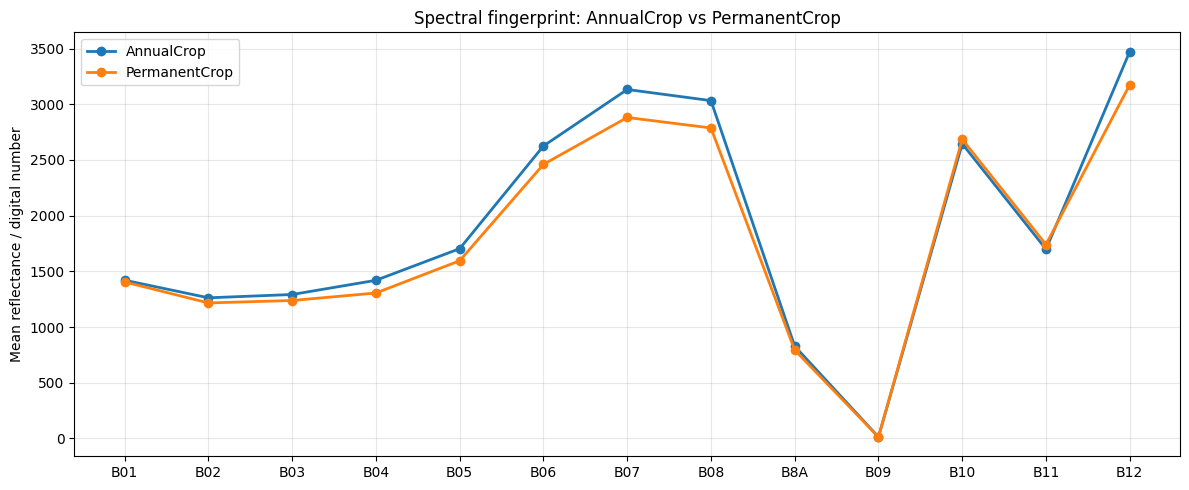

Largest mean reflectance differences: PermanentCrop - AnnualCrop
B12   -297.06
B07   -251.28
B08   -245.50
B06   -165.20
B04   -113.94
B05   -108.28
dtype: float64


,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B10,B11,B12
class,,,,,,,,,,,,,
AnnualCrop,1420.52,1262.67,1292.32,1419.76,1703.75,2625.38,3132.40,3032.53,828.22,13.28,2645.43,1698.86,3472.42
PermanentCrop,1405.03,1216.62,1238.47,1305.82,1595.47,2460.17,2881.12,2787.03,793.16,13.31,2685.06,1740.60,3175.36


In [34]:
def mean_band_profile(root, classes, max_per_class=300):
    rows = []
    for cls in classes:
        files = sorted(glob.glob(os.path.join(root, cls, "*.tif")))[:max_per_class]
        for fp in tqdm(files, desc=f"profile {cls}"):
            arr = read_tif(fp)
            rows.append({"class": cls, **{band: float(arr[i].mean()) for i, band in enumerate(BAND_NAMES)}})
    return pd.DataFrame(rows)

crop_classes = [c for c in ["AnnualCrop", "PermanentCrop"] if c in class_to_idx]
crop_profiles = mean_band_profile(TRAIN_DIR, crop_classes, max_per_class=300)
profile_mean = crop_profiles.groupby("class")[BAND_NAMES].mean()
profile_std = crop_profiles.groupby("class")[BAND_NAMES].std()

plt.figure(figsize=(12, 5))
x = np.arange(len(BAND_NAMES))
for cls in crop_classes:
    y = profile_mean.loc[cls].values
    plt.plot(x, y, marker="o", linewidth=2, label=cls)
plt.xticks(x, BAND_NAMES)
plt.ylabel("Mean reflectance / digital number")
plt.title("Spectral fingerprint: AnnualCrop vs PermanentCrop")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if len(crop_classes) == 2:
    diff = (profile_mean.loc["PermanentCrop"] - profile_mean.loc["AnnualCrop"]).sort_values(key=np.abs, ascending=False)
    print("Largest mean reflectance differences: PermanentCrop - AnnualCrop")
    print(diff.round(2).head(6))

profile_mean.round(2)


### 17.5 Physical validation of test predictions

After classification, we compute NDVI/NDWI for the test patches and group them by the model's predicted class. This checks whether the model's predictions make physical sense: patches predicted as vegetation classes should have higher NDVI, while patches predicted as water classes should have stronger water-index values.


In [35]:
def compute_test_index_table(test_dir, pred_csv, max_files=None):
    preds = pd.read_csv(pred_csv)
    pred_map = dict(zip(preds["img_id"].astype(str), preds["predicted_label"]))
    paths = sorted(glob.glob(os.path.join(test_dir, "*.tif")))
    if max_files is not None:
        paths = paths[:max_files]

    rows = []
    for fp in tqdm(paths, desc="test spectral indices"):
        img_id = os.path.splitext(os.path.basename(fp))[0]
        vals = patch_indices(read_tif(fp))
        vals.update({"img_id": img_id, "predicted_label": pred_map.get(img_id)})
        rows.append(vals)
    return pd.DataFrame(rows).dropna(subset=["predicted_label"])

# Use max_files=1000 for a quick run, or None for the full test set.
test_index_df = compute_test_index_table(TEST_DIR, PRED_CSV, max_files=None)
test_index_df.head()


test spectral indices:   0%|          | 0/4050 [00:00<?, ?it/s]

,ndvi_mean,ndwi_mean,mndwi_mean,ndvi_gt_02,ndwi_gt_02,mndwi_gt_02,img_id,predicted_label
0,0.610437,-0.556707,-0.015198,0.968506,0.0,0.052002,test_1,AnnualCrop
1,0.552788,-0.497487,-0.112925,0.815918,0.0,0.000000,test_10,AnnualCrop
2,0.456238,-0.413326,-0.119897,0.659912,0.0,0.000000,test_100,AnnualCrop
3,0.362505,-0.282461,-0.019057,0.988525,0.0,0.154053,test_1000,HerbaceousVegetation
4,0.303086,-0.321502,-0.186969,0.984863,0.0,0.000000,test_1001,HerbaceousVegetation


In [36]:
test_summary = (test_index_df.groupby("predicted_label")
                .agg(count=("img_id", "count"),
                     median_ndvi=("ndvi_mean", "median"),
                     median_mndwi=("mndwi_mean", "median"),
                     vegetation_fraction=("ndvi_gt_02", "median"),
                     water_fraction=("mndwi_gt_02", "median"))
                .sort_values("median_ndvi", ascending=False))

test_summary


,count,median_ndvi,median_mndwi,vegetation_fraction,water_fraction
predicted_label,,,,,
Forest,448,0.724875,0.132037,1.000000,0.105713
Pasture,305,0.666031,0.008460,0.999512,0.000488
Highway,373,0.448027,-0.029461,0.845947,0.014893
HerbaceousVegetation,450,0.364800,-0.149441,0.984741,0.000000
AnnualCrop,449,0.352646,-0.084124,0.710449,0.000977
Residential,450,0.351516,-0.100557,0.812622,0.001465
PermanentCrop,376,0.338158,-0.161768,0.883911,0.000000
River,373,0.331829,0.216554,0.645752,0.367432
Industrial,376,0.216305,-0.050223,0.432495,0.019531


/tmp/ipykernel_3182/4010327273.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([test_index_df.loc[test_index_df["predicted_label"] == cls, "ndvi_mean"] for cls in ndvi_order],
/tmp/ipykernel_3182/4010327273.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([test_index_df.loc[test_index_df["predicted_label"] == cls, "mndwi_mean"] for cls in water_order],


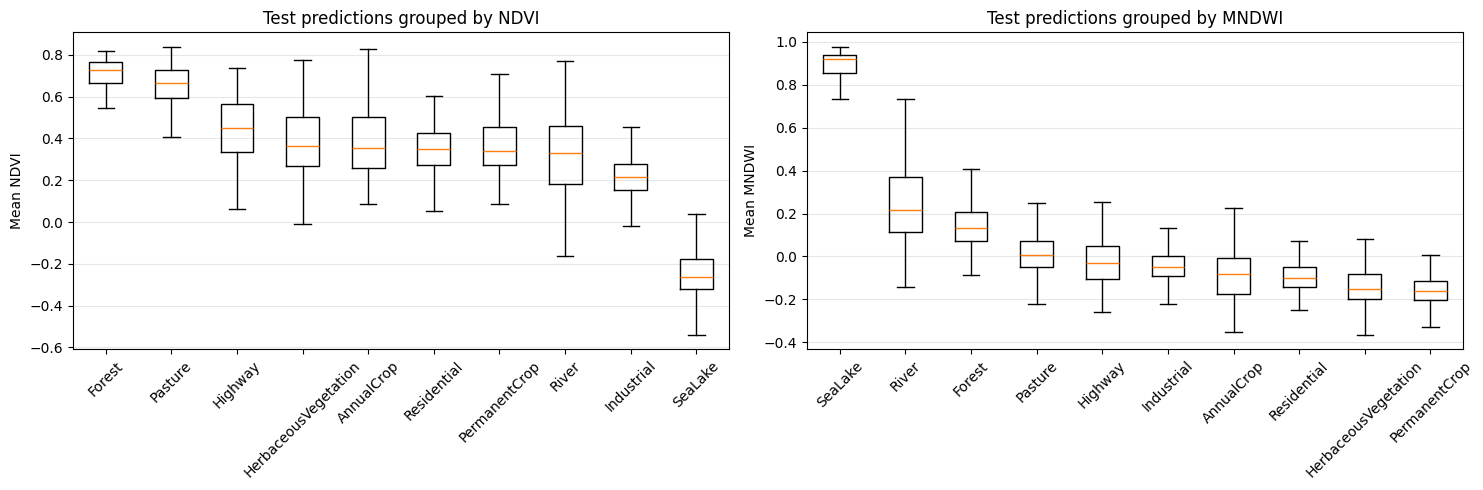

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ndvi_order = test_index_df.groupby("predicted_label")["ndvi_mean"].median().sort_values(ascending=False).index
ax[0].boxplot([test_index_df.loc[test_index_df["predicted_label"] == cls, "ndvi_mean"] for cls in ndvi_order],
              labels=ndvi_order, showfliers=False)
ax[0].set_title("Test predictions grouped by NDVI")
ax[0].set_ylabel("Mean NDVI")
ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(axis="y", alpha=0.3)

water_order = test_index_df.groupby("predicted_label")["mndwi_mean"].median().sort_values(ascending=False).index
ax[1].boxplot([test_index_df.loc[test_index_df["predicted_label"] == cls, "mndwi_mean"] for cls in water_order],
              labels=water_order, showfliers=False)
ax[1].set_title("Test predictions grouped by MNDWI")
ax[1].set_ylabel("Mean MNDWI")
ax[1].tick_params(axis="x", rotation=45)
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### 17.6 Short report conclusion template

Use the printed summaries and plots above to write a small data science story. For example: vegetation classes show high NDVI, built-up classes show low NDVI, water classes have stronger MNDWI/NDWI, and crop classes differ in red-edge/near-infrared reflectance. This connects the model's labels to physical environmental meaning instead of only reporting classification accuracy.


In [38]:
print("Bonus interpretation draft:")
print("1. Vegetation classes such as Forest/Pasture/Crop generally show higher NDVI, meaning stronger photosynthetic vegetation signal.")
print("2. Built-up classes such as Industrial/Residential/Highway show lower NDVI, indicating less vegetation cover.")
print("3. Water classes such as River/SeaLake show stronger water-index values, especially with MNDWI.")
print("4. AnnualCrop and PermanentCrop can be compared through their spectral signature, especially red-edge and NIR bands.")
print("5. Test-set predictions can be physically validated: predicted vegetation classes should have high NDVI, and predicted water classes should have high water-index values.")


Bonus interpretation draft:
1. Vegetation classes such as Forest/Pasture/Crop generally show higher NDVI, meaning stronger photosynthetic vegetation signal.
2. Built-up classes such as Industrial/Residential/Highway show lower NDVI, indicating less vegetation cover.
3. Water classes such as River/SeaLake show stronger water-index values, especially with MNDWI.
4. AnnualCrop and PermanentCrop can be compared through their spectral signature, especially red-edge and NIR bands.
5. Test-set predictions can be physically validated: predicted vegetation classes should have high NDVI, and predicted water classes should have high water-index values.
